# Player Market Value Model Results

This notebook summarizes the position-specific market value modeling pipeline.

It is designed to answer four questions:

1. What features are in each model specification?
2. Which model won for each position and lag/no-lag setup?
3. How did validation and test performance compare across candidates?
4. What do the 2025-26 predictions look like?

Update the paths and settings in the next cell if you rerun the pipeline with different outputs.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False


def detect_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for candidate in candidates:
        if (candidate / "data" / "merged").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not detect project root containing data/merged and scripts directories.")


ROOT = detect_project_root()
NOTEBOOKS_DIR = ROOT / "notebooks"
SCRIPTS_DIR = ROOT / "scripts"

# Ensure notebook can import project scripts regardless of where Jupyter was launched from.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

COMPARISON_PATH = ROOT / "data" / "merged" / "player_market_value_model_comparison.csv"
PREDICTIONS_PATH = ROOT / "data" / "merged" / "player_market_value_predictions_2025_26.csv"
FEATURE_IMPORTANCE_PATH = ROOT / "data" / "merged" / "player_market_value_feature_importance_top10.csv"

# Change this if you want the notebook to highlight winners by a different test metric.
SELECTION_METRIC = "test_mae"
LOWER_IS_BETTER = {"test_mae", "test_rmse", "test_rmsle"}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

comparison = pd.read_csv(COMPARISON_PATH)
predictions = pd.read_csv(PREDICTIONS_PATH)

for col in ["uses_last_market_value", "selected_for_position_setup"]:
    if col in comparison.columns:
        comparison[col] = comparison[col].astype(bool)
if "uses_last_market_value" in predictions.columns:
    predictions["uses_last_market_value"] = predictions["uses_last_market_value"].astype(bool)

print(f"Detected project root: {ROOT}")
print(f"Loaded {len(comparison):,} model comparison rows from {COMPARISON_PATH}")
print(f"Loaded {len(predictions):,} prediction rows from {PREDICTIONS_PATH}")

Detected project root: /Users/james/Desktop/sports_analytics_final_project
Loaded 48 model comparison rows from /Users/james/Desktop/sports_analytics_final_project/data/merged/player_market_value_model_comparison.csv
Loaded 4,114 prediction rows from /Users/james/Desktop/sports_analytics_final_project/data/merged/player_market_value_predictions_2025_26.csv


## Model Specification Reference

The pipeline estimates three feature sets for every position. The table below is a compact data dictionary for those specs. For the with-last-market-value setup, `last_market_value_log` is added to each spec; the target remains log market value for all setups.

In [2]:
MODEL_SPECS = {
    "model_1_simplified_performance": [
        "log_minutes", "minutes_share_3420", "start_rate", "player_age", "player_age_sq",
        "goals_assists_per90", "xg_xa_per90", "api_avg_rating", "transfermarkt_match_level",
    ],
    "model_2_full_performance_age_exposure": [
        "goals_assists_per90", "xg_xa_per90", "np_xg_xa_per90", "understat_xg_chain_per90",
        "understat_xg_buildup_per90", "api_avg_rating", "shot_on_target_rate", "goal_conversion_rate",
        "dribble_success_rate", "duel_win_rate", "log_minutes", "minutes_share_3420", "start_rate",
        "player_age", "player_age_sq", "age_peak_gap", "transfermarkt_match_level",
    ],
    "model_3_position_percentiles": [
        "goals_assists_per90_pos_season_pct", "xg_xa_per90_pos_season_pct",
        "np_xg_xa_per90_pos_season_pct", "understat_xg_chain_per90_pos_season_pct",
        "understat_xg_buildup_per90_pos_season_pct", "api_tackles_total_per90_pos_season_pct",
        "api_duels_won_per90_pos_season_pct", "api_passes_key_per90_pos_season_pct",
        "shot_on_target_rate_pos_season_pct", "duel_win_rate_pos_season_pct",
        "api_minutes_pos_season_pct", "api_avg_rating_pos_season_pct", "age_peak_gap",
        "is_u21", "is_over30", "transfermarkt_match_level",
    ],
}

spec_rows = []
for spec_name, features in MODEL_SPECS.items():
    spec_rows.append({
        "model_spec": spec_name,
        "feature_count_no_lag": len(features),
        "feature_count_with_last_value": len(features) + 1,
        "features": ", ".join(features),
    })

pd.DataFrame(spec_rows)

,model_spec,feature_count_no_lag,feature_count_with_last_value,features
0,model_1_simplified_performance,9,10,"log_minutes, minutes_share_3420, start_rate, player_age, player_age_sq, goals_assists_per90, xg_xa_per90, api_avg_ra..."
1,model_2_full_performance_age_exposure,17,18,"goals_assists_per90, xg_xa_per90, np_xg_xa_per90, understat_xg_chain_per90, understat_xg_buildup_per90, api_avg_rati..."
2,model_3_position_percentiles,16,17,"goals_assists_per90_pos_season_pct, xg_xa_per90_pos_season_pct, np_xg_xa_per90_pos_season_pct, understat_xg_chain_pe..."


## Selected Models

Each position has two selected models: one trained without prior market value and one trained with prior market value. Selection is based on the configured test metric, using test data only after validation-set tuning.

In [3]:
selected = comparison[comparison["selected_for_position_setup"]].copy()
selected = selected.sort_values(["position", "uses_last_market_value"])

selected_display_cols = [
    "position", "uses_last_market_value", "model_spec", "algorithm",
    "validation_mae", "validation_rmse", "validation_rmsle", "validation_r2",
    "test_mae", "test_rmse", "test_rmsle", "test_r2", "selected_hyperparameters",
]
selected[selected_display_cols].style.format({
    "validation_mae": "{:,.0f}",
    "validation_rmse": "{:,.0f}",
    "validation_rmsle": "{:.3f}",
    "validation_r2": "{:.3f}",
    "test_mae": "{:,.0f}",
    "test_rmse": "{:,.0f}",
    "test_rmsle": "{:.3f}",
    "test_r2": "{:.3f}",
})

,position,uses_last_market_value,model_spec,algorithm,validation_mae,validation_rmse,validation_rmsle,validation_r2,test_mae,test_rmse,test_rmsle,test_r2,selected_hyperparameters
0,D,False,model_2_full_performance_age_exposure,lightgbm,"4,888,533","8,836,904",0.811,0.532,"5,468,447","9,377,891",0.892,0.498,"{""regressor__learning_rate"": 0.05, ""regressor__max_depth"": 5, ""regressor__min_child_samples"": 30, ""regressor__n_estimators"": 200, ""regressor__num_leaves"": 15}"
6,D,True,model_1_simplified_performance,lightgbm,"2,703,487","4,966,194",0.478,0.852,"2,634,960","4,679,819",0.503,0.875,"{""regressor__learning_rate"": 0.05, ""regressor__max_depth"": 5, ""regressor__min_child_samples"": 60, ""regressor__n_estimators"": 200, ""regressor__num_leaves"": 15}"
12,F,False,model_3_position_percentiles,lightgbm,"6,176,595","12,902,318",0.810,0.644,"7,439,343","14,960,754",0.860,0.575,"{""regressor__learning_rate"": 0.05, ""regressor__max_depth"": 5, ""regressor__min_child_samples"": 60, ""regressor__n_estimators"": 200, ""regressor__num_leaves"": 15}"
18,F,True,model_2_full_performance_age_exposure,lightgbm,"3,197,122","6,762,293",0.457,0.902,"3,476,921","7,647,400",0.486,0.889,"{""regressor__learning_rate"": 0.05, ""regressor__max_depth"": 5, ""regressor__min_child_samples"": 30, ""regressor__n_estimators"": 200, ""regressor__num_leaves"": 15}"
24,G,False,model_2_full_performance_age_exposure,lightgbm,"3,766,859","6,638,301",0.860,0.507,"3,721,255","5,956,009",0.862,0.558,"{""regressor__learning_rate"": 0.05, ""regressor__max_depth"": 5, ""regressor__min_child_samples"": 30, ""regressor__n_estimators"": 200, ""regressor__num_leaves"": 7}"
30,G,True,model_3_position_percentiles,ridge,"2,015,346","3,829,774",0.438,0.836,"2,062,413","3,708,026",0.478,0.829,"{""regressor__alpha"": 0.1}"
36,M,False,model_2_full_performance_age_exposure,lightgbm,"6,492,345","12,074,863",0.835,0.620,"7,271,124","13,661,772",0.874,0.577,"{""regressor__learning_rate"": 0.05, ""regressor__max_depth"": 5, ""regressor__min_child_samples"": 30, ""regressor__n_estimators"": 200, ""regressor__num_leaves"": 15}"
42,M,True,model_1_simplified_performance,lightgbm,"3,480,590","6,897,515",0.481,0.876,"3,827,291","7,658,745",0.482,0.867,"{""regressor__learning_rate"": 0.05, ""regressor__max_depth"": 3, ""regressor__min_child_samples"": 30, ""regressor__n_estimators"": 200, ""regressor__num_leaves"": 15}"


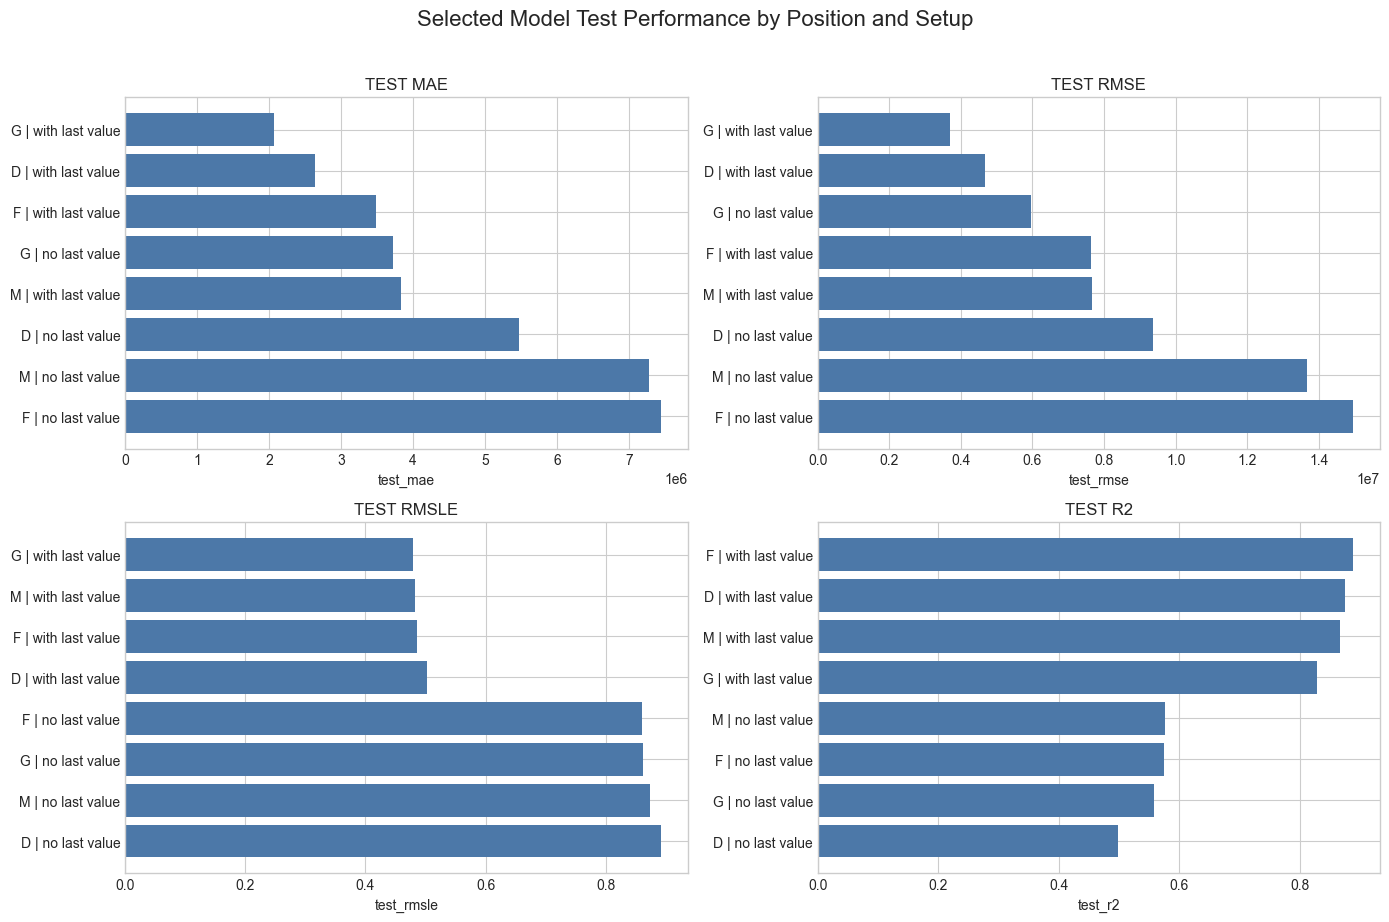

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = ["test_mae", "test_rmse", "test_rmsle", "test_r2"]

plot_df = selected.copy()
plot_df["setup"] = np.where(plot_df["uses_last_market_value"], "with last value", "no last value")
plot_df["position_setup"] = plot_df["position"] + " | " + plot_df["setup"]

for ax, metric in zip(axes.flatten(), metrics):
    ordered = plot_df.sort_values(metric, ascending=metric != "test_r2")
    ax.barh(ordered["position_setup"], ordered[metric], color="#4C78A8")
    ax.set_title(metric.replace("_", " ").upper())
    ax.set_xlabel(metric)
    ax.invert_yaxis()

fig.suptitle("Selected Model Test Performance by Position and Setup", fontsize=16, y=1.02)
fig.tight_layout()

## Baseline: Predict Next Value = Last Value

This baseline uses a naive persistence rule:

- `predicted_market_value_eur = last_market_value_eur`

It is evaluated on the same **test season** used by the training script (latest completed season before the prediction season), using rows with valid positive target and last value. We report `R²` and error metrics in EUR for overall and per-position performance.

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TRAINING_DATA_PATH = ROOT / "data" / "merged" / "player_value_modeling_2015_16_to_2024_25.csv"
train_df = pd.read_csv(TRAINING_DATA_PATH)

for col in ["season", "target_market_value_eur", "last_market_value_eur"]:
    if col in train_df.columns:
        train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

prediction_season = int(predictions["season"].dropna().iloc[0]) if len(predictions) else 2025
completed_seasons = sorted(
    int(s) for s in train_df["season"].dropna().unique() if int(s) < prediction_season
)
test_season = completed_seasons[-1]

baseline_test = train_df[
    (train_df["season"] == test_season)
    & train_df["target_market_value_eur"].notna()
    & train_df["last_market_value_eur"].notna()
    & (train_df["target_market_value_eur"] > 0)
    & (train_df["last_market_value_eur"] > 0)
].copy()

baseline_test["baseline_pred_eur"] = baseline_test["last_market_value_eur"]

def baseline_metrics(df_slice: pd.DataFrame) -> dict:
    y_true = df_slice["target_market_value_eur"].to_numpy(dtype=float)
    y_pred = df_slice["baseline_pred_eur"].to_numpy(dtype=float)
    return {
        "rows": len(df_slice),
        "baseline_mae": mean_absolute_error(y_true, y_pred),
        "baseline_rmse": mean_squared_error(y_true, y_pred, squared=False),
        "baseline_r2": r2_score(y_true, y_pred) if len(df_slice) > 1 else np.nan,
    }

overall_row = baseline_metrics(baseline_test)
overall_row["position"] = "ALL"

by_position_rows = []
for position, group in baseline_test.groupby("model_position", dropna=False):
    row = baseline_metrics(group)
    row["position"] = str(position)
    by_position_rows.append(row)

baseline_summary = pd.DataFrame([overall_row] + by_position_rows)[
    ["position", "rows", "baseline_mae", "baseline_rmse", "baseline_r2"]
].sort_values("position")

print(f"Baseline evaluated on test season: {test_season}")
baseline_summary.style.format(
    {
        "rows": "{:,.0f}",
        "baseline_mae": "{:,.0f}",
        "baseline_rmse": "{:,.0f}",
        "baseline_r2": "{:.3f}",
    }
)

Baseline evaluated on test season: 2024


/Users/james/opt/anaconda3/envs/compstats_proj/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/james/opt/anaconda3/envs/compstats_proj/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/james/opt/anaconda3/envs/compstats_proj/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users/james/opt/anaconda3/envs/compstats_proj/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: 

,position,rows,baseline_mae,baseline_rmse,baseline_r2
0,ALL,"2,106","4,703,122","8,729,209",0.781
1,D,697,"3,811,836","6,785,332",0.737
2,F,456,"5,610,307","9,970,635",0.811
3,G,173,"2,756,647","4,844,549",0.707
4,M,780,"5,400,929","10,063,392",0.770


## Candidate Comparison

These views show all model/spec combinations, not just the winners. They make it easier to see whether one algorithm dominates, whether the lag setup helps, and whether validation performance tracked test performance.

In [6]:
ranked = comparison.copy()
ranked["setup"] = np.where(ranked["uses_last_market_value"], "with last value", "no last value")
ranked["candidate"] = ranked["model_spec"] + " | " + ranked["algorithm"]
ranked["rank_within_position_setup"] = ranked.groupby(["position", "uses_last_market_value"])[SELECTION_METRIC].rank(
    method="first",
    ascending=SELECTION_METRIC in LOWER_IS_BETTER,
).astype(int)

ranked.sort_values(["position", "uses_last_market_value", "rank_within_position_setup"])[[
    "position", "setup", "rank_within_position_setup", "candidate", "validation_mae", "test_mae", "test_rmse", "test_rmsle", "test_r2"
]].style.format({
    "validation_mae": "{:,.0f}",
    "test_mae": "{:,.0f}",
    "test_rmse": "{:,.0f}",
    "test_rmsle": "{:.3f}",
    "test_r2": "{:.3f}",
})

,position,setup,rank_within_position_setup,candidate,validation_mae,test_mae,test_rmse,test_rmsle,test_r2
0,D,no last value,1,model_2_full_performance_age_exposure | lightgbm,"4,888,533","5,468,447","9,377,891",0.892,0.498
1,D,no last value,2,model_3_position_percentiles | lightgbm,"4,940,895","5,589,933","9,890,344",0.900,0.442
2,D,no last value,3,model_2_full_performance_age_exposure | ridge,"5,609,327","5,833,298","10,518,765",0.948,0.369
3,D,no last value,4,model_3_position_percentiles | ridge,"5,587,681","5,947,272","10,818,804",0.936,0.332
4,D,no last value,5,model_1_simplified_performance | lightgbm,"5,715,475","5,965,519","10,601,119",0.967,0.359
5,D,no last value,6,model_1_simplified_performance | ridge,"6,077,226","6,365,842","11,637,562",0.982,0.227
6,D,with last value,1,model_1_simplified_performance | lightgbm,"2,703,487","2,634,960","4,679,819",0.503,0.875
7,D,with last value,2,model_3_position_percentiles | lightgbm,"2,620,760","2,656,159","4,765,559",0.502,0.870
8,D,with last value,3,model_2_full_performance_age_exposure | lightgbm,"2,659,806","2,682,316","4,754,127",0.504,0.871
9,D,with last value,4,model_2_full_performance_age_exposure | ridge,"3,019,061","2,896,614","5,273,100",0.543,0.841


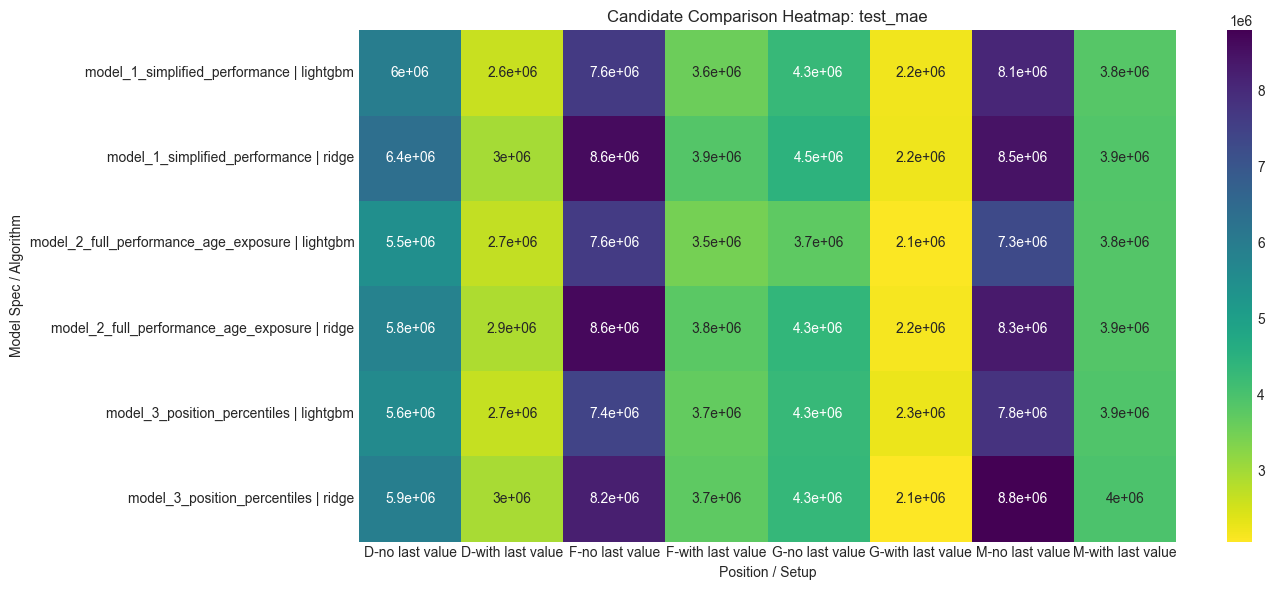

In [7]:
heatmap_df = ranked.pivot_table(
    index="candidate",
    columns=["position", "setup"],
    values=SELECTION_METRIC,
    aggfunc="min",
)

fig, ax = plt.subplots(figsize=(14, 6))
if HAS_SEABORN:
    sns.heatmap(heatmap_df, annot=True, fmt=".2g", cmap="viridis_r", ax=ax)
else:
    im = ax.imshow(heatmap_df.fillna(np.nan), aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels([" | ".join(col) for col in heatmap_df.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    fig.colorbar(im, ax=ax)

ax.set_title(f"Candidate Comparison Heatmap: {SELECTION_METRIC}")
ax.set_xlabel("Position / Setup")
ax.set_ylabel("Model Spec / Algorithm")
fig.tight_layout()

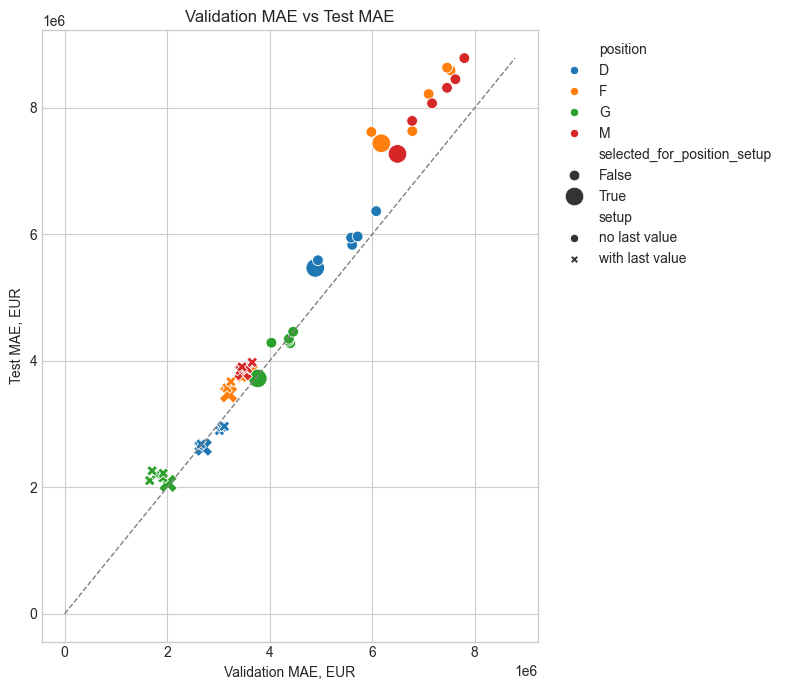

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
scatter_df = ranked.copy()
scatter_df["setup"] = np.where(scatter_df["uses_last_market_value"], "with last value", "no last value")

if HAS_SEABORN:
    sns.scatterplot(
        data=scatter_df,
        x="validation_mae",
        y="test_mae",
        hue="position",
        style="setup",
        size="selected_for_position_setup",
        sizes={False: 60, True: 180},
        ax=ax,
    )
else:
    for position, part in scatter_df.groupby("position"):
        ax.scatter(part["validation_mae"], part["test_mae"], label=position, alpha=0.8)

max_value = max(scatter_df["validation_mae"].max(), scatter_df["test_mae"].max())
ax.plot([0, max_value], [0, max_value], linestyle="--", color="gray", linewidth=1)
ax.set_title("Validation MAE vs Test MAE")
ax.set_xlabel("Validation MAE, EUR")
ax.set_ylabel("Test MAE, EUR")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

## Test Error Distribution By Position (2x2)

This chart uses the selected model for each position/setup, refits on train+validation seasons, predicts the held-out test season, and plots error (`predicted - actual`) in EUR.

- Vertical line at 0 indicates unbiased prediction.
- Wider spread means less stable accuracy.
- Systematic left/right shift indicates under/over-valuation bias.

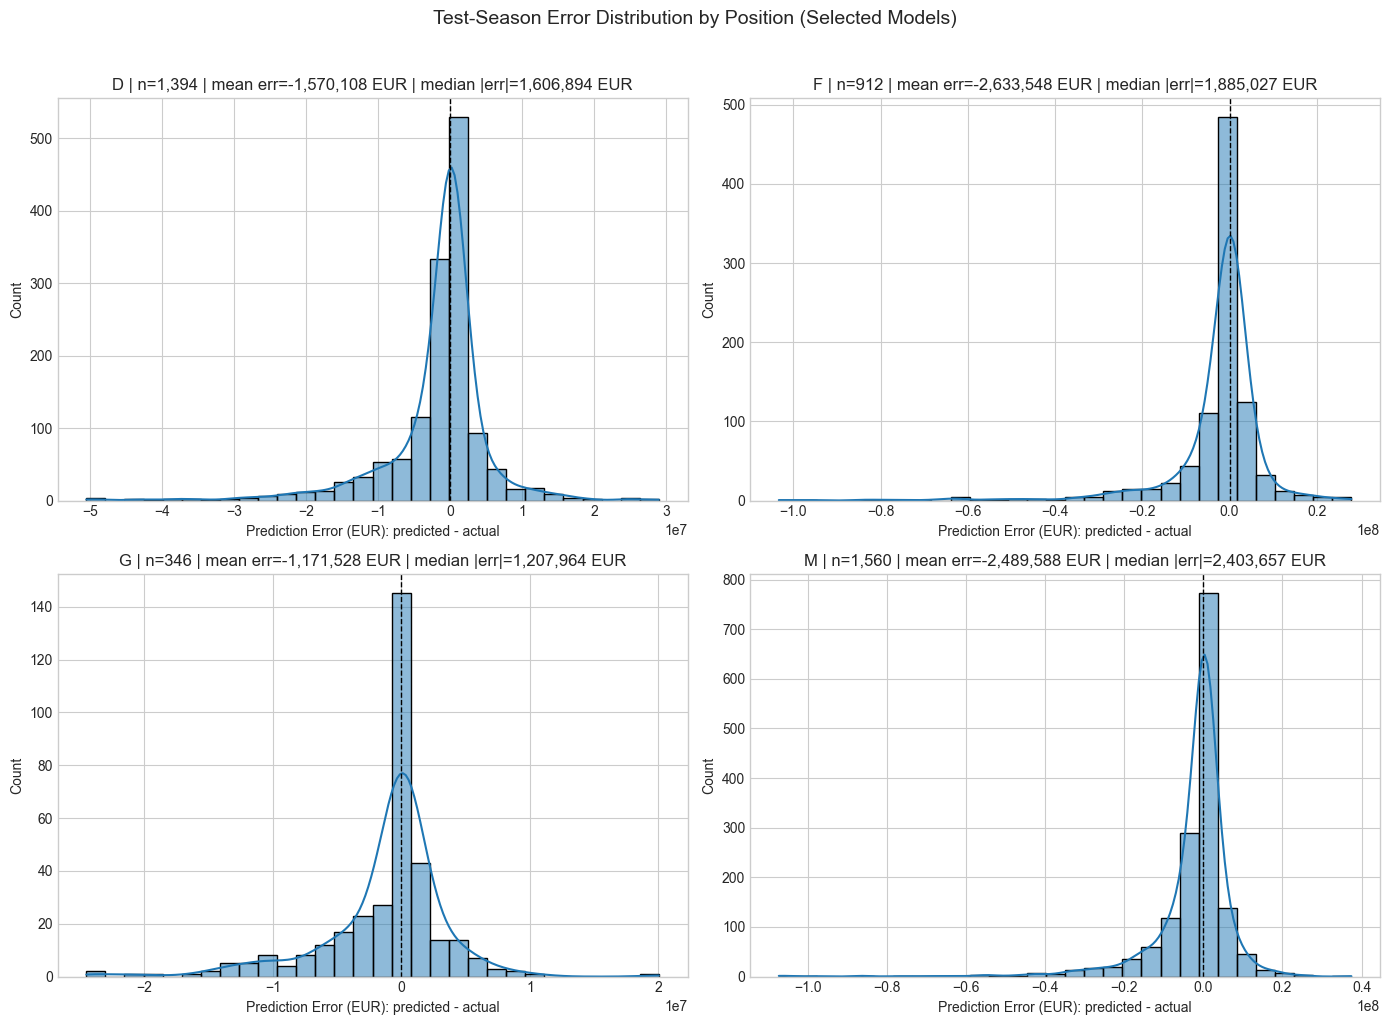

,model_position,rows,mean_error_eur,median_abs_error_eur,rmse_eur
0,D,1394,-1.570108e+06,1.606894e+06,7.410990e+06
1,F,912,-2.633548e+06,1.885027e+06,1.188080e+07
2,G,346,-1.171528e+06,1.207964e+06,4.961023e+06
3,M,1560,-2.489588e+06,2.403657e+06,1.107475e+07


In [9]:
import model_player_market_values_by_position as mv

# Recreate test-season residuals using the same training logic as the pipeline.
train_model_df = mv.coerce_model_columns(pd.read_csv(TRAINING_DATA_PATH))
split = mv.infer_split(
    train_model_df,
    validation_season=None,
    test_season=None,
    prediction_season=prediction_season,
)

selected_rows = comparison[comparison["selected_for_position_setup"]].copy()
selected_rows["best_params"] = selected_rows["selected_hyperparameters"].map(json.loads)

test_error_frames = []
for _, row in selected_rows.iterrows():
    position = str(row["position"])
    uses_last = bool(row["uses_last_market_value"])
    model_spec = row["model_spec"]
    algorithm = row["algorithm"]
    best_params = row["best_params"]

    features = mv.features_for_spec(model_spec, uses_last)

    position_df = train_model_df[train_model_df["model_position"].astype(str) == position].copy()
    setup_df = mv.filter_setup_rows(position_df, uses_last)

    train_df = setup_df[setup_df["season"].isin(split.train_seasons)].copy()
    validation_df = setup_df[setup_df["season"] == split.validation_season].copy()
    test_df = setup_df[setup_df["season"] == split.test_season].copy()
    if test_df.empty:
        continue

    train_val_df = pd.concat([train_df, validation_df], ignore_index=True)
    model = mv.make_pipeline(features, algorithm)
    model.set_params(**best_params)
    model.fit(train_val_df[features], mv.target_for_setup(train_val_df, uses_last))

    raw_test_pred = model.predict(test_df[features])
    pred_eur = mv.market_value_predictions(test_df, raw_test_pred, uses_last)

    out = test_df[["player_season_uid", "player_name", "season", "model_position", "target_market_value_eur"]].copy()
    out["predicted_market_value_eur"] = pred_eur
    out["error_eur"] = out["predicted_market_value_eur"] - out["target_market_value_eur"]
    out["abs_error_eur"] = out["error_eur"].abs()
    out["uses_last_market_value"] = uses_last
    out["model_spec"] = model_spec
    out["algorithm"] = algorithm
    test_error_frames.append(out)

test_error_df = pd.concat(test_error_frames, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.flatten()
positions_order = ["D", "F", "G", "M"]

for i, pos in enumerate(positions_order):
    ax = axes[i]
    pos_df = test_error_df[test_error_df["model_position"].astype(str) == pos]
    if pos_df.empty:
        ax.set_title(f"{pos}: no test rows")
        ax.axis("off")
        continue

    if HAS_SEABORN:
        sns.histplot(pos_df["error_eur"], bins=30, kde=True, ax=ax)
    else:
        ax.hist(pos_df["error_eur"], bins=30, alpha=0.85)

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    mean_err = pos_df["error_eur"].mean()
    med_abs = pos_df["abs_error_eur"].median()
    ax.set_title(
        f"{pos} | n={len(pos_df):,} | mean err={mean_err:,.0f} EUR | median |err|={med_abs:,.0f} EUR"
    )
    ax.set_xlabel("Prediction Error (EUR): predicted - actual")
    ax.set_ylabel("Count")

plt.suptitle("Test-Season Error Distribution by Position (Selected Models)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

display(
    test_error_df.groupby("model_position", as_index=False).agg(
        rows=("player_season_uid", "count"),
        mean_error_eur=("error_eur", "mean"),
        median_abs_error_eur=("abs_error_eur", "median"),
        rmse_eur=("error_eur", lambda x: np.sqrt(np.mean(np.square(x)))),
    ).sort_values("model_position")
)

## Final 2025-26 Predictions

The prediction file contains both setup outputs for each player-season row when prior market value is available. The next cells summarize coverage, prediction distributions, and the biggest differences between the no-lag and with-last-value estimates.

In [10]:
prediction_summary = (
    predictions.assign(setup=np.where(predictions["uses_last_market_value"], "with last value", "no last value"))
    .groupby(["model_position", "setup"])
    .agg(
        rows=("player_season_uid", "count"),
        players=("player_season_uid", "nunique"),
        median_prediction=("predicted_market_value_eur", "median"),
        mean_prediction=("predicted_market_value_eur", "mean"),
        p90_prediction=("predicted_market_value_eur", lambda s: s.quantile(0.90)),
        max_prediction=("predicted_market_value_eur", "max"),
    )
    .reset_index()
)

prediction_summary.style.format({
    "median_prediction": "{:,.0f}",
    "mean_prediction": "{:,.0f}",
    "p90_prediction": "{:,.0f}",
    "max_prediction": "{:,.0f}",
})

,model_position,setup,rows,players,median_prediction,mean_prediction,p90_prediction,max_prediction
0,D,no last value,690,690,"4,198,675","7,031,501","15,614,729","44,947,300"
1,D,with last value,690,690,"5,451,207","9,937,433","24,706,507","86,350,782"
2,F,no last value,488,488,"6,100,297","10,896,373","24,990,923","108,774,684"
3,F,with last value,488,488,"5,789,791","11,655,553","27,940,225","147,469,940"
4,G,no last value,150,150,"3,986,321","6,229,474","14,511,507","37,207,698"
5,G,with last value,150,150,"3,925,559","7,476,688","19,206,624","49,043,993"
6,M,no last value,729,729,"5,642,926","9,983,675","23,262,846","99,461,929"
7,M,with last value,729,729,"7,638,518","14,272,705","33,256,093","208,087,816"


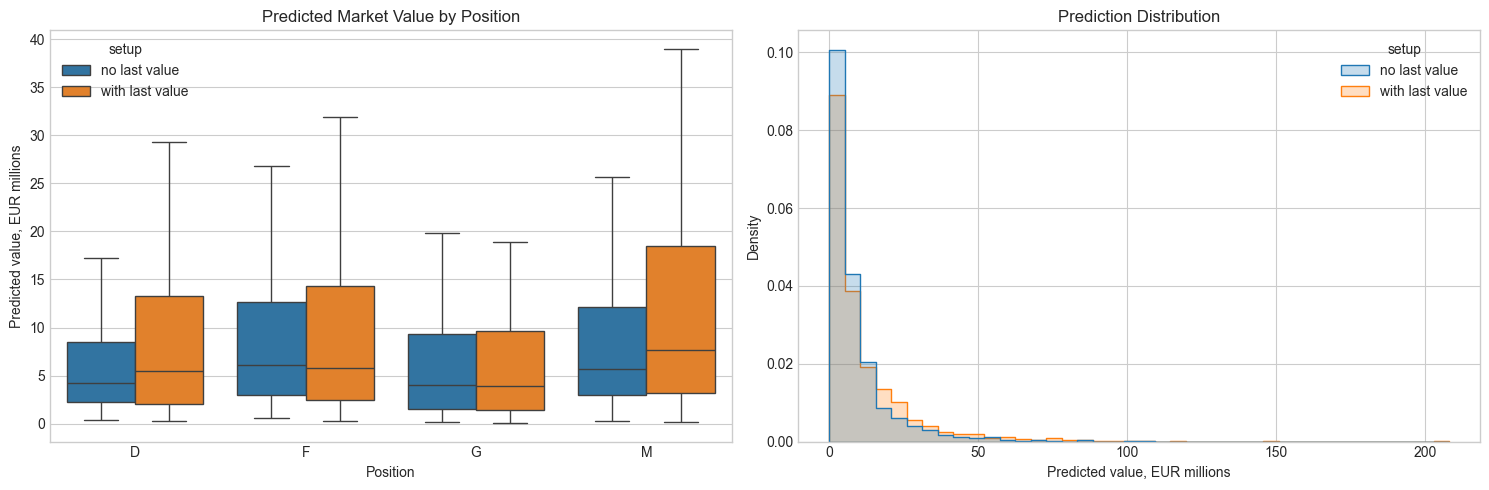

In [11]:
plot_predictions = predictions.copy()
plot_predictions["setup"] = np.where(plot_predictions["uses_last_market_value"], "with last value", "no last value")
plot_predictions["predicted_market_value_millions"] = plot_predictions["predicted_market_value_eur"] / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if HAS_SEABORN:
    sns.boxplot(
        data=plot_predictions,
        x="model_position",
        y="predicted_market_value_millions",
        hue="setup",
        showfliers=False,
        ax=axes[0],
    )
    sns.histplot(
        data=plot_predictions,
        x="predicted_market_value_millions",
        hue="setup",
        bins=40,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[1],
    )
else:
    plot_predictions.boxplot(
        column="predicted_market_value_millions",
        by=["model_position", "setup"],
        ax=axes[0],
        rot=45,
    )
    for setup, part in plot_predictions.groupby("setup"):
        axes[1].hist(part["predicted_market_value_millions"], bins=40, alpha=0.5, density=True, label=setup)
    axes[1].legend()

axes[0].set_title("Predicted Market Value by Position")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Predicted value, EUR millions")
axes[1].set_title("Prediction Distribution")
axes[1].set_xlabel("Predicted value, EUR millions")
axes[1].set_ylabel("Density")
fig.tight_layout()

In [18]:
prediction_wide = predictions.pivot_table(
    index=["player_season_uid", "player_name", "season", "team_name", "model_position", "last_market_value_eur"],
    columns="uses_last_market_value",
    values="predicted_market_value_eur",
    aggfunc="mean",
).rename(columns={False: "prediction_no_last_value", True: "prediction_with_last_value"}).reset_index()

prediction_wide["abs_difference_vs_last_value"] = abs(
    prediction_wide["prediction_with_last_value"] - prediction_wide["last_market_value_eur"]
)

prediction_wide.sort_values("abs_difference_vs_last_value", ascending=False).head(20).style.format({
    "last_market_value_eur": "{:,.0f}",
    "prediction_no_last_value": "{:,.0f}",
    "prediction_with_last_value": "{:,.0f}",
    "absolute_difference": "{:,.0f}",
})

uses_last_market_value,player_season_uid,player_name,season,team_name,model_position,last_market_value_eur,prediction_no_last_value,prediction_with_last_value,abs_difference_vs_last_value
1272,129718,Jude Bellingham,2025,Real Madrid,M,"180,000,000","39,085,648","79,290,498",100709501.601289
1444,181812,Jamal Musiala,2025,Bayern München,M,"140,000,000","7,662,715","59,112,023",80887976.718759
408,2864,Alexander Isak,2025,Liverpool,F,"120,000,000","8,821,141","47,481,913",72518086.944567
1530,203224,Florian Wirtz,2025,Liverpool,M,"140,000,000","28,926,510","73,770,835",66229164.837447
15,44,Rodri,2025,Manchester City,M,"110,000,000","23,912,301","52,241,039",57758961.485864
286,1460,Bukayo Saka,2025,Arsenal,F,"150,000,000","55,873,678","94,170,226",55829774.361588
174,762,Vinícius Júnior,2025,Real Madrid,F,"170,000,000","83,918,135","118,008,806",51991193.584831
456,6716,Alexis Mac Allister,2025,Liverpool,M,"100,000,000","9,669,687","50,668,403",49331596.683718
493,10009,Rodrygo,2025,Real Madrid,F,"90,000,000","15,823,020","45,739,670",44260330.332826
3,9,Achraf Hakimi,2025,Paris Saint Germain,D,"80,000,000","10,471,986","38,472,435",41527564.594026


## How to Read This Notebook

- `no last value` and `with last value` models both predict log market value and exponentiate back into EUR.
- `with last value` means prior value is included as a feature (and row eligibility filter), not a different target definition.
- MAE, RMSE, RMSLE, and R2 are all evaluated in actual EUR market value space.
- Validation metrics are used for hyperparameter tuning; test metrics are used for final model comparison.
- Re-run `model_player_market_values_by_position.py` first, then re-run this notebook to refresh every chart.

## 2024 Market Value Reference Distribution

This section computes the market value distribution for the most recent completed training season. Use it as a reference scale when judging 2025-26 predictions.

In [13]:
TRAINING_DATA_PATH = ROOT / "data" / "merged" / "player_value_modeling_2015_16_to_2024_25.csv"

training_values = pd.read_csv(
    TRAINING_DATA_PATH,
    usecols=["season", "player_name", "team_name", "model_position", "target_market_value_eur"],
)
training_values["season"] = pd.to_numeric(training_values["season"], errors="coerce")
training_values["target_market_value_eur"] = pd.to_numeric(training_values["target_market_value_eur"], errors="coerce")

last_completed_season = int(training_values["season"].dropna().max())
last_season_values = training_values[
    (training_values["season"] == last_completed_season)
    & training_values["target_market_value_eur"].notna()
    & (training_values["target_market_value_eur"] > 0)
].copy()

percentiles = [0, .01, .05, .10, .25, .50, .75, .90, .95, .99, 1]
percentile_labels = ["min", "p01", "p05", "p10", "p25", "median", "p75", "p90", "p95", "p99", "max"]

overall_distribution = pd.DataFrame({
    "stat": ["players", "mean", "std"] + percentile_labels,
    "value_eur": [
        len(last_season_values),
        last_season_values["target_market_value_eur"].mean(),
        last_season_values["target_market_value_eur"].std(),
        *[last_season_values["target_market_value_eur"].quantile(q) for q in percentiles],
    ],
})

print(f"Reference season: {last_completed_season}")
overall_distribution.style.format({"value_eur": "{:,.0f}"})

Reference season: 2024


,stat,value_eur
0,players,"2,106"
1,mean,"12,597,234"
2,std,"18,674,568"
3,min,"75,000"
4,p01,"202,500"
5,p05,"562,500"
6,p10,"900,000"
7,p25,"2,000,000"
8,median,"6,000,000"
9,p75,"15,000,000"


In [14]:
position_distribution = (
    last_season_values
    .groupby("model_position")["target_market_value_eur"]
    .agg(
        players="count",
        mean="mean",
        std="std",
        min="min",
        p10=lambda s: s.quantile(.10),
        p25=lambda s: s.quantile(.25),
        median="median",
        p75=lambda s: s.quantile(.75),
        p90=lambda s: s.quantile(.90),
        p95=lambda s: s.quantile(.95),
        p99=lambda s: s.quantile(.99),
        max="max",
    )
    .reset_index()
)

position_distribution.style.format({
    "mean": "{:,.0f}", "std": "{:,.0f}", "min": "{:,.0f}", "p10": "{:,.0f}",
    "p25": "{:,.0f}", "median": "{:,.0f}", "p75": "{:,.0f}", "p90": "{:,.0f}",
    "p95": "{:,.0f}", "p99": "{:,.0f}", "max": "{:,.0f}",
})

,model_position,players,mean,std,min,p10,p25,median,p75,p90,p95,p99,max
0,D,697,"10,311,944","13,247,452","100,000","900,000","2,000,000","5,000,000","14,000,000","25,000,000","35,000,000","65,200,000","80,000,000"
1,F,456,"14,513,871","22,970,128","75,000","1,000,000","2,275,000","6,000,000","16,000,000","35,000,000","60,000,000","109,000,000","180,000,000"
2,G,173,"7,158,382","8,980,418","100,000","500,000","900,000","3,000,000","10,000,000","20,000,000","25,000,000","40,000,000","40,000,000"
3,M,780,"14,725,160","21,015,486","100,000","1,200,000","2,725,000","7,000,000","18,000,000","35,000,000","50,000,000","102,100,000","200,000,000"


,value_bucket,players,share
0,<0.5M,61,2.9%
1,0.5-1M,160,7.6%
2,1-2.5M,337,16.0%
3,2.5-5M,359,17.0%
4,5-10M,399,18.9%
5,10-20M,347,16.5%
6,20-50M,343,16.3%
7,50-100M,83,3.9%
8,100M+,17,0.8%


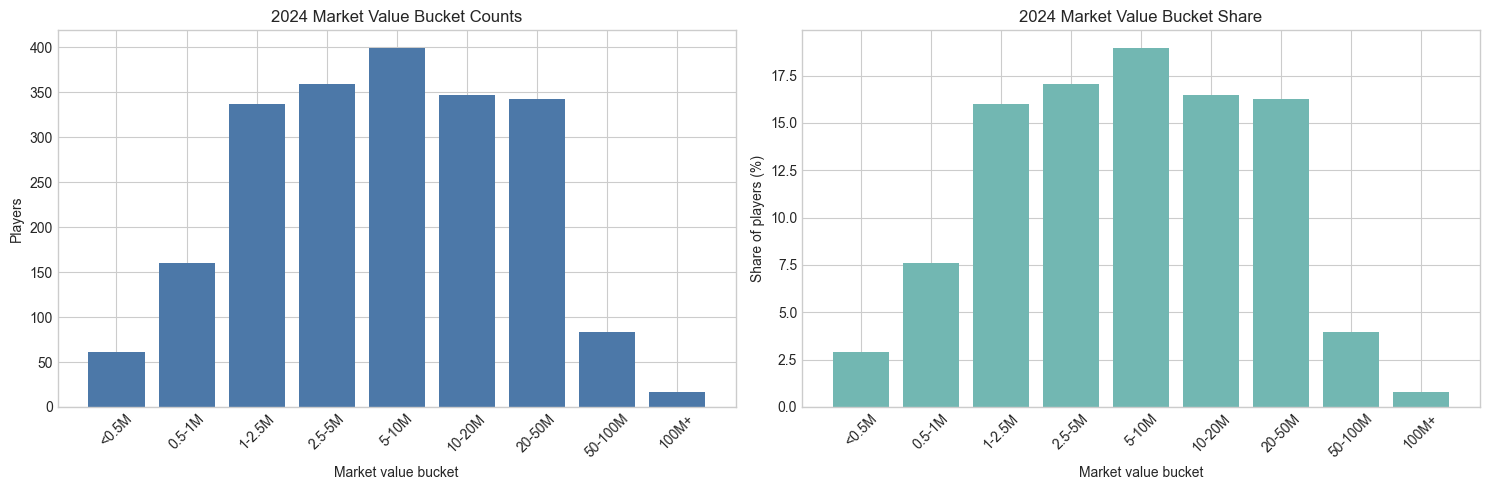

In [15]:
value_bins = [0, 500_000, 1_000_000, 2_500_000, 5_000_000, 10_000_000, 20_000_000, 50_000_000, 100_000_000, np.inf]
value_labels = ["<0.5M", "0.5-1M", "1-2.5M", "2.5-5M", "5-10M", "10-20M", "20-50M", "50-100M", "100M+"]

bucket_distribution = last_season_values.copy()
bucket_distribution["value_bucket"] = pd.cut(
    bucket_distribution["target_market_value_eur"],
    bins=value_bins,
    labels=value_labels,
    right=False,
)
bucket_distribution = (
    bucket_distribution["value_bucket"]
    .value_counts(sort=False)
    .rename_axis("value_bucket")
    .reset_index(name="players")
)
bucket_distribution["share"] = bucket_distribution["players"] / len(last_season_values)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(bucket_distribution["value_bucket"].astype(str), bucket_distribution["players"], color="#4C78A8")
axes[0].set_title(f"{last_completed_season} Market Value Bucket Counts")
axes[0].set_xlabel("Market value bucket")
axes[0].set_ylabel("Players")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(bucket_distribution["value_bucket"].astype(str), bucket_distribution["share"] * 100, color="#72B7B2")
axes[1].set_title(f"{last_completed_season} Market Value Bucket Share")
axes[1].set_xlabel("Market value bucket")
axes[1].set_ylabel("Share of players (%)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
bucket_distribution.style.format({"share": "{:.1%}"})